# EDA

In [1]:
import os
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns   
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings("ignore")
from src.aggregation.agg import ElectricityAggregator
from src.visualization.tariff_plot import plot_monthly_adoption, plot_monthly_share, plot_tariff_group_counts, plot_tariff_group_cumulative 
from src.visualization.consumption_plot import plot_consumption, plot_tariff_adoption_by_usage, plot_event_study_tariff
from src.visualization import peak_plot as pp

## Load Data

In [2]:
# data paths
DATA_DIR = "mock_data"
OUT_BASE_DIR = "output"

MATDATA_PATH = os.path.join(DATA_DIR, "meter_data_500.snappy.parquet")
TARIFF_PATH  = os.path.join(DATA_DIR, "tariff_100.csv")
SURVEY_PATH  = os.path.join(DATA_DIR, "survey_50.csv")

In [3]:
# Electricity meter data
pf = pq.ParquetFile(MATDATA_PATH)
table = pf.read(columns=["aID", "TIDPUNKT", "TIDPUNKT_DAG", "FORBRUKNING_KWH"])
meter_data = table.to_pandas()

print("Unique households:", len(meter_data["aID"].unique())) # unique households
print("Unique days:", len(meter_data["TIDPUNKT_DAG"].unique())) # unique days
display(meter_data.head(3))

Unique households: 500
Unique days: 782


,aID,TIDPUNKT,TIDPUNKT_DAG,FORBRUKNING_KWH
0,735999166200000851,2024-01-01 00:00:00+00:00,2024-01-01,0.283425
1,735999166200000851,2024-01-01 01:00:00+00:00,2024-01-01,0.300204
2,735999166200000851,2024-01-01 02:00:00+00:00,2024-01-01,0.260809


In [4]:
# Tariff data
tariff_df = pd.read_csv(TARIFF_PATH, sep=",")
print(f"tariff rows: {len(tariff_df):,}") # Tariff number 
display(tariff_df.head(3))

# Survey data
# survey_month_result[month_result["price"] == "high"] = pd.read_csv(SURVEY_PATH)
# print(f"survey rows: {len(survey_month_result[month_result["price"] == "high"]):,}") # Survey number
# display(survey_month_result[month_result["price"] == "high"].head(3))


tariff rows: 100


,Produktnamn,Startdatum,GS1-nr.
0,GENAB Tidsindelad 6 kW Villa,2025-06-01,735999166200288372
1,GENAB Tidsindelad 6 kW Villa,2025-04-01,735999166200186244
2,GENAB Tidsindelad 6 kW Villa,2025-03-01,735999166200055594


# Aggregate electricity meter data 

In [5]:
agg = ElectricityAggregator(meter_data, tariff_df)

Initializing ElectricityAggregator...
Loaded 9,372,500 rows


In [6]:
# Monthly
month_result = agg.run(
    freq="month",
    agg_method=["top3_mean", "variance", "mean"],
    use_price=True,
    add_user_group_col=[0.25, 0.75],
    output_path=os.path.join(OUT_BASE_DIR, "monthly_agg.parquet")
    )


Electricity aggregation start
Rows: 9,372,500
Frequency: month
Aggregation: ['top3_mean', 'variance', 'mean']
Include price split (all/high/low): True
Add User groups: [0.25, 0.75]
Merging tariff data...
Tariff merge done (1.92s)
Creating usage groups...
Usage groups created (2.18s)
Aggregating per household...
Aggregation done (19.39s)
Saving parquet...
Saved.
Total runtime: 23.52s


In [7]:
month_result.head()

,aID,TIDPUNKT,price,tariff_active,peak1_consumption,peak2_consumption,peak3_consumption,peak1_time,peak2_time,peak3_time,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,2024-01-01,all,0,0.785776,0.771093,0.766627,2024-01-08 19:00:00,2024-01-06 18:00:00,2024-01-07 19:00:00,0.774499,0.022423,0.378508,NaT,NaN,6334.57217,low
1,735999166200000851,2024-01-01,high,0,0.785776,0.739500,0.709986,2024-01-08 19:00:00,2024-01-01 19:00:00,2024-01-17 19:00:00,0.745087,0.023170,0.386800,NaT,NaN,6334.57217,low
2,735999166200000851,2024-01-01,low,0,0.771093,0.766627,0.758738,2024-01-06 18:00:00,2024-01-07 19:00:00,2024-01-20 18:00:00,0.765486,0.021895,0.372936,NaT,NaN,6334.57217,low
3,735999166200000851,2024-02-01,all,0,0.790864,0.782472,0.780223,2024-02-24 19:00:00,2024-02-25 20:00:00,2024-02-15 19:00:00,0.784520,0.023686,0.379428,NaT,NaN,6334.57217,low
4,735999166200000851,2024-02-01,high,0,0.780223,0.743266,0.720648,2024-02-15 19:00:00,2024-02-07 19:00:00,2024-02-09 19:00:00,0.748046,0.024711,0.385561,NaT,NaN,6334.57217,low


In [8]:
# Hourly
hour_result = agg.run(
    freq="hour",
    agg_method=["mean"],
    use_price=True,
    add_user_group_col=[0.25, 0.75],
    )


Electricity aggregation start
Rows: 9,372,500
Frequency: hour
Aggregation: ['mean']
Include price split (all/high/low): True
Add User groups: [0.25, 0.75]
Aggregating per household...
Aggregation done (6.94s)
Total runtime: 6.94s


In [9]:
hour_result.head(3)

,aID,TIDPUNKT,price,tariff_active,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,0,all,0,0.217603,NaT,NaN,6334.57217,low
1,735999166200000851,1,all,0,0.217461,NaT,NaN,6334.57217,low
2,735999166200000851,2,all,0,0.214411,NaT,NaN,6334.57217,low


In [10]:
# Week & Weekend
weekday_result = agg.run(
    freq="weekday",
    agg_method=["mean"],
    use_price=True,
    add_user_group_col=[0.25, 0.75],
    )


Electricity aggregation start
Rows: 9,372,500
Frequency: weekday
Aggregation: ['mean']
Include price split (all/high/low): True
Add User groups: [0.25, 0.75]
Aggregating per household...
Aggregation done (7.22s)
Total runtime: 7.22s


# Tariff

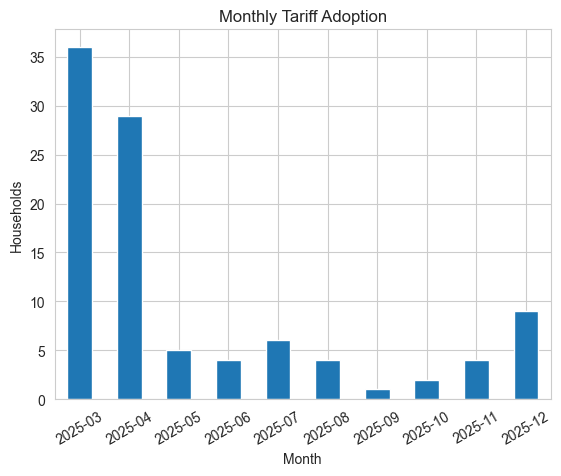

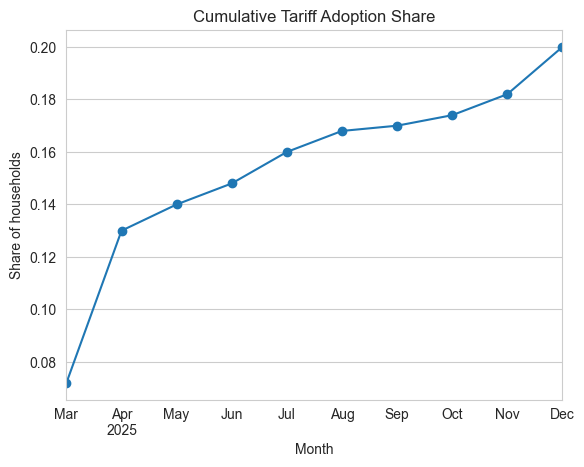

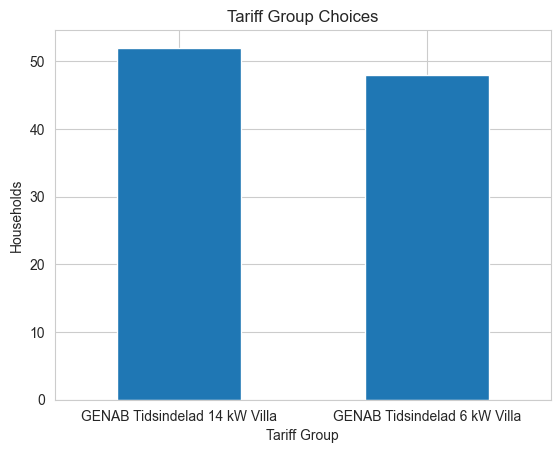

<Figure size 640x480 with 0 Axes>

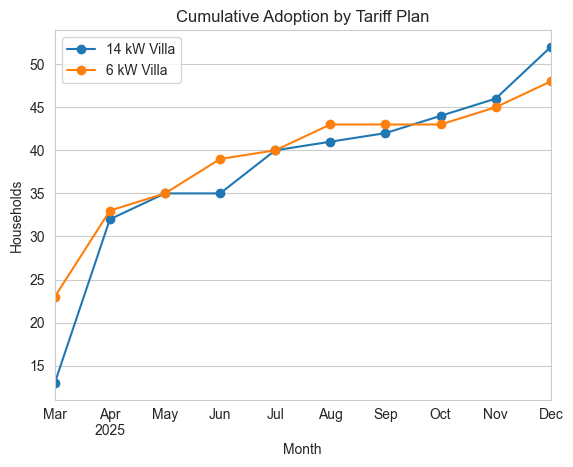

In [11]:
plot_monthly_adoption(tariff_df)
plt.show()

plot_monthly_share(tariff_df, total_households=500)
plt.show()

plot_tariff_group_counts(tariff_df)
plt.show()

plot_tariff_group_cumulative(tariff_df)
plt.show()

## Electricity data

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

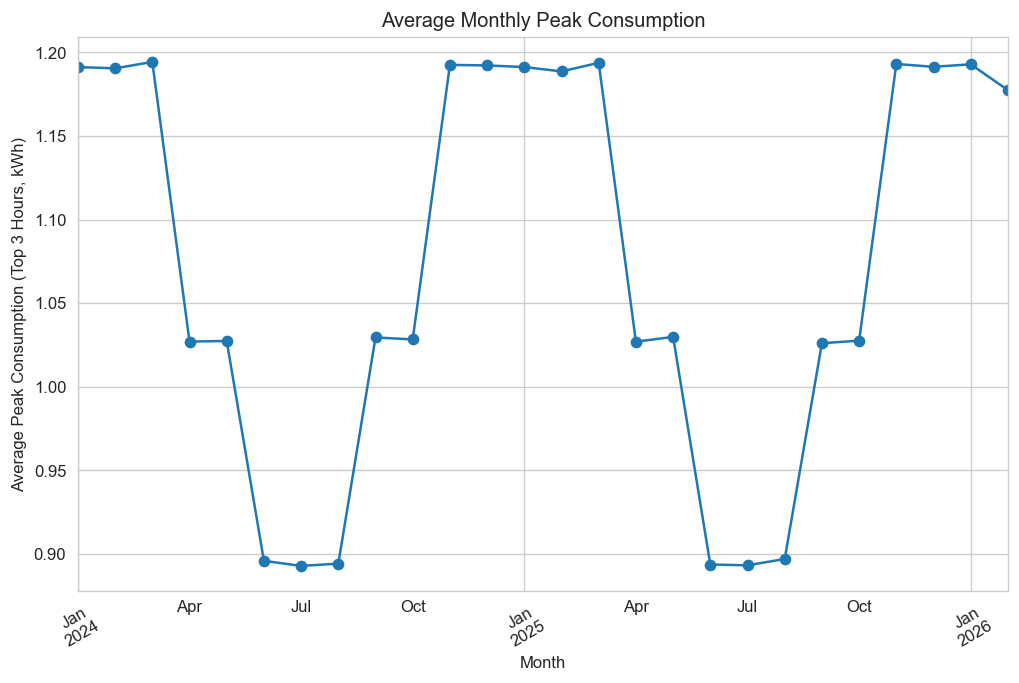

In [12]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

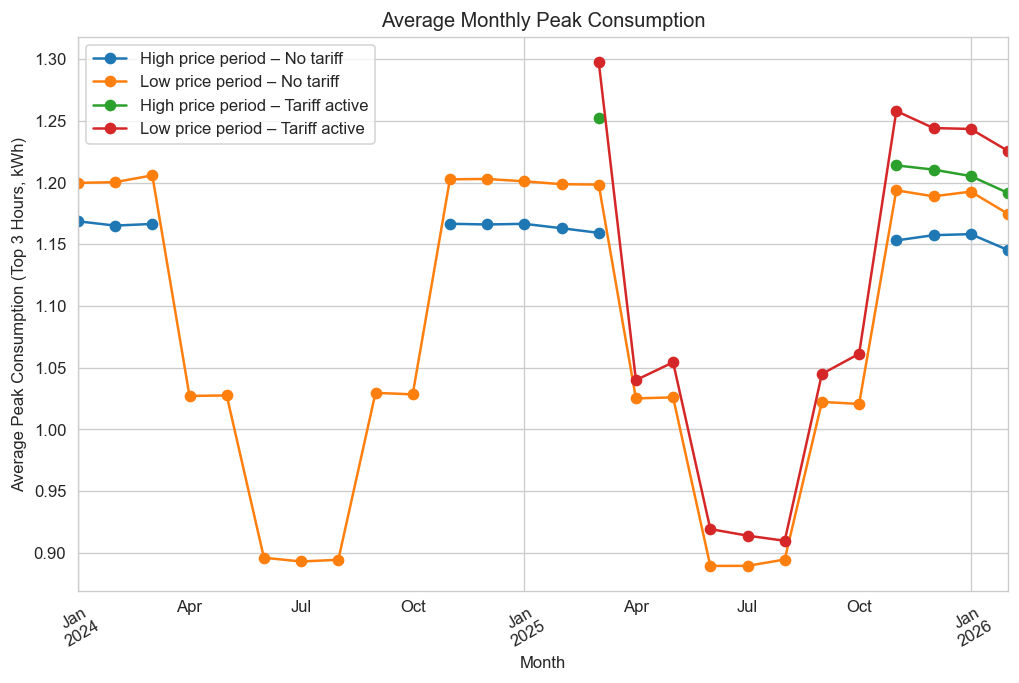

In [13]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

<Axes: title={'center': 'Average Hourly Consumption Profile'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

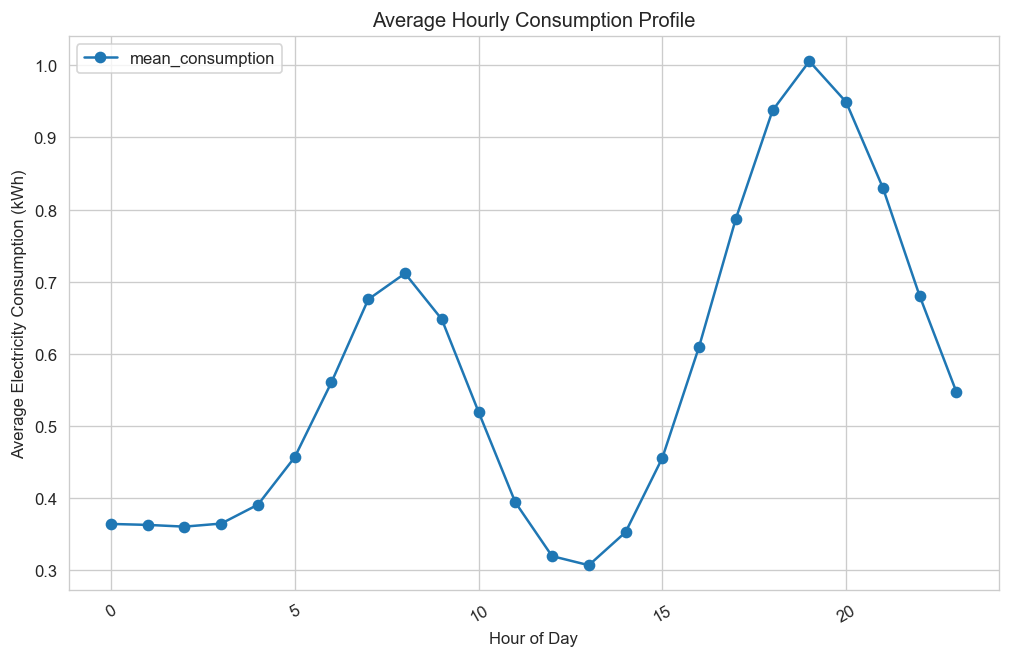

In [14]:
# hour
plot_consumption(
    hour_result,
    group_by="hour",
    value_col="mean_consumption",
)

In [15]:
hour_result.groupby("tariff_active").size()

tariff_active
0    30500
1     6100
dtype: int64

<Axes: title={'center': 'Average Hourly Consumption Profile'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

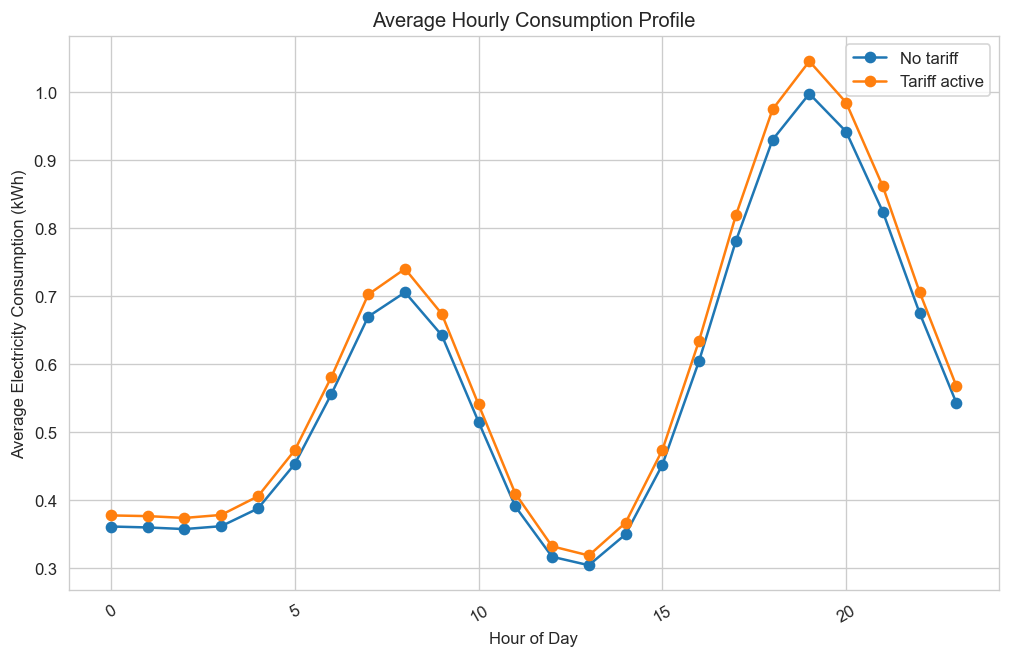

In [16]:
# hour
plot_consumption(
    hour_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"]
)

<Axes: title={'center': 'Average Consumption by Day of Week'}, xlabel='Day of Week', ylabel='Average Electricity Consumption (kWh)'>

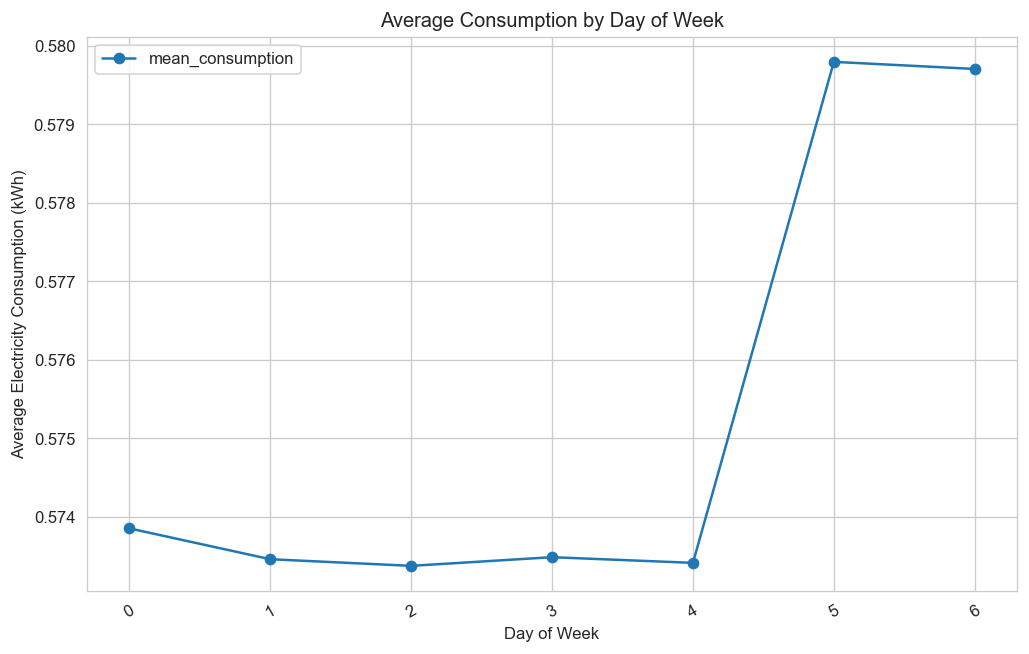

In [17]:
# weekend, week
plot_consumption(
    weekday_result,
    group_by="weekday",
    value_col="mean_consumption",
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

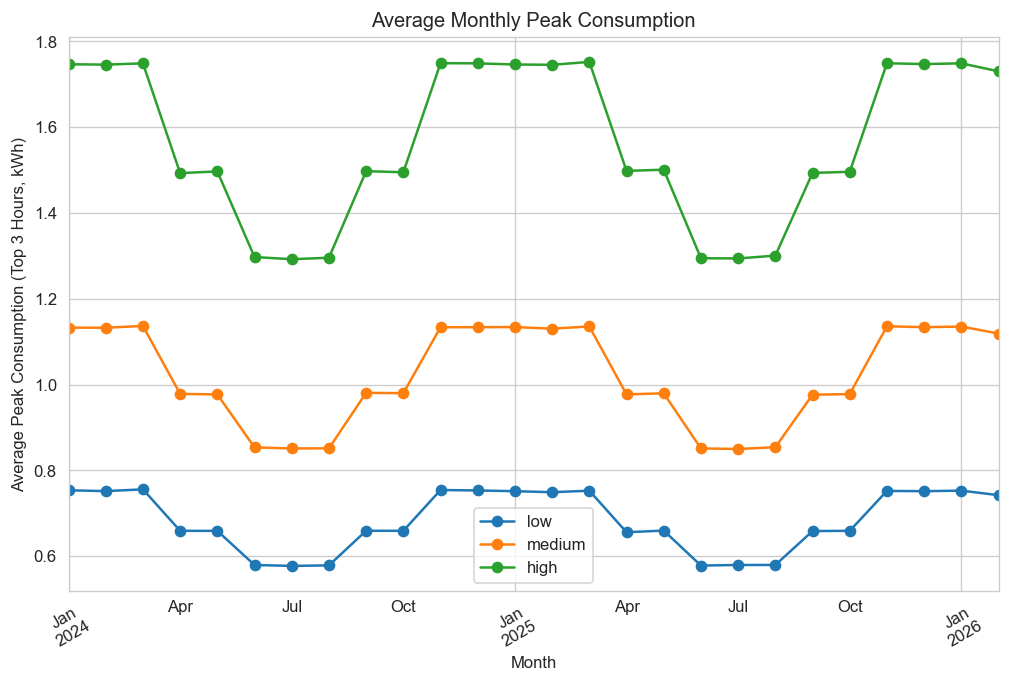

In [18]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

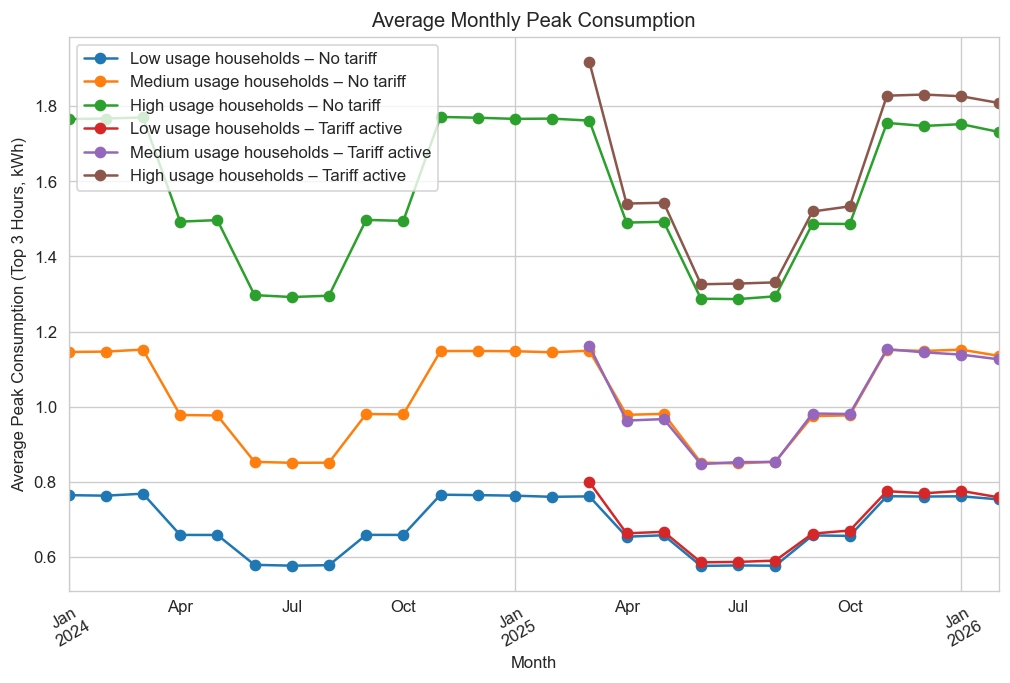

In [19]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"]
)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

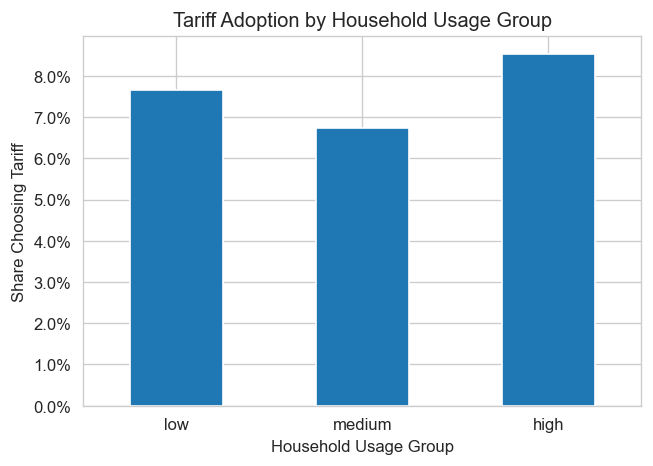

In [20]:
plot_tariff_adoption_by_usage(
    month_result,
    figsize=(6, 4)
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

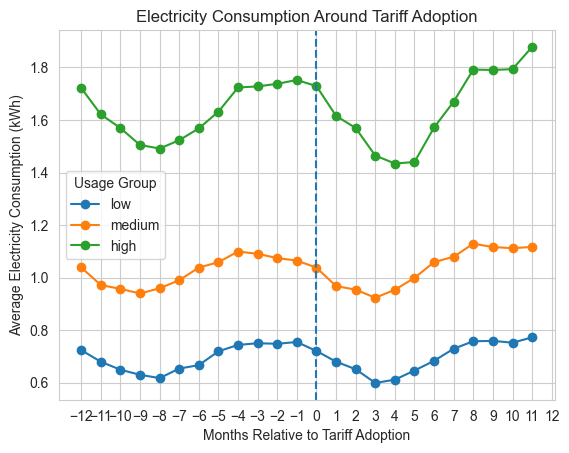

In [21]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result,
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

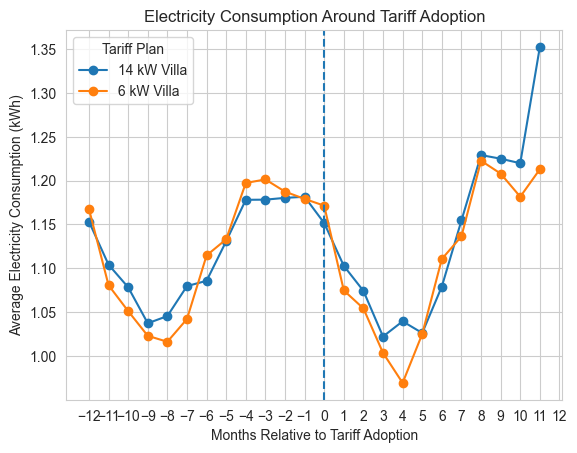

In [22]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result,
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

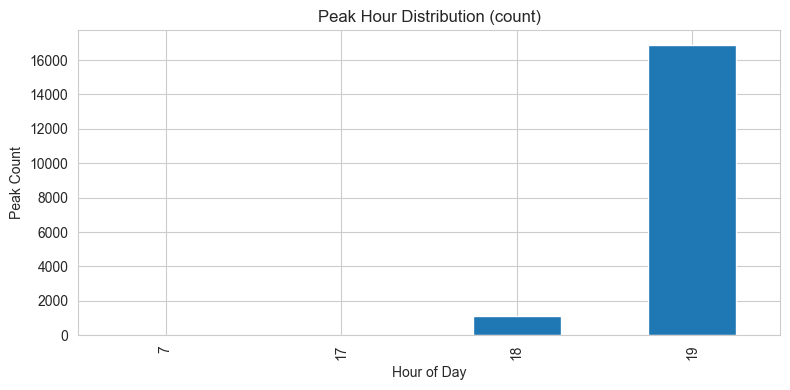

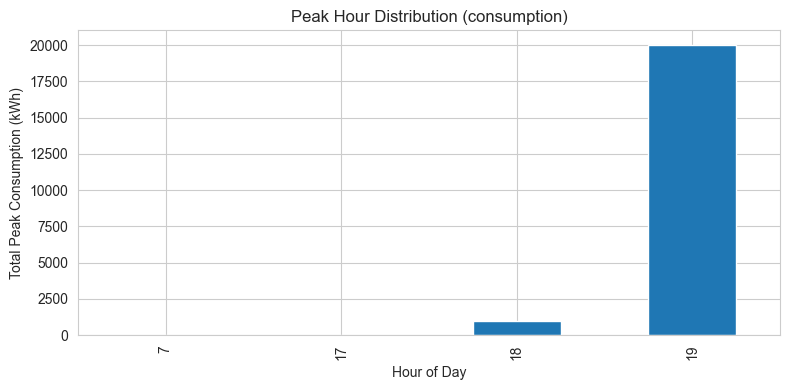

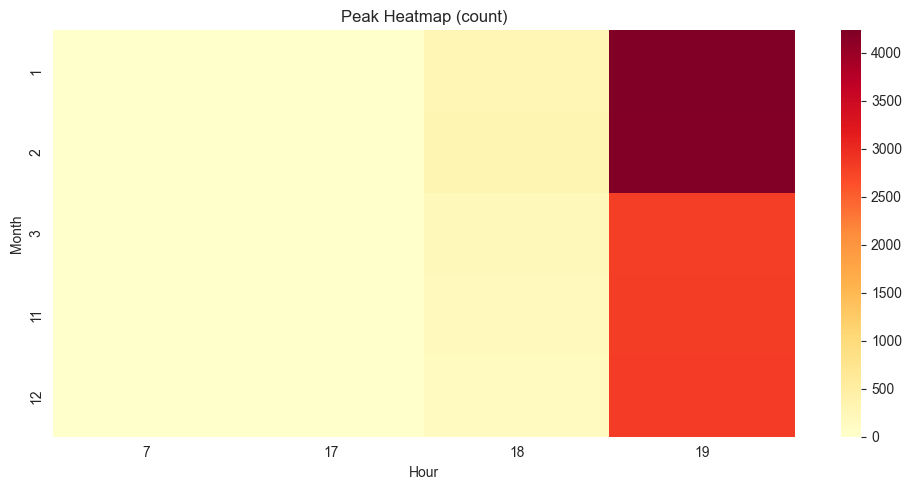

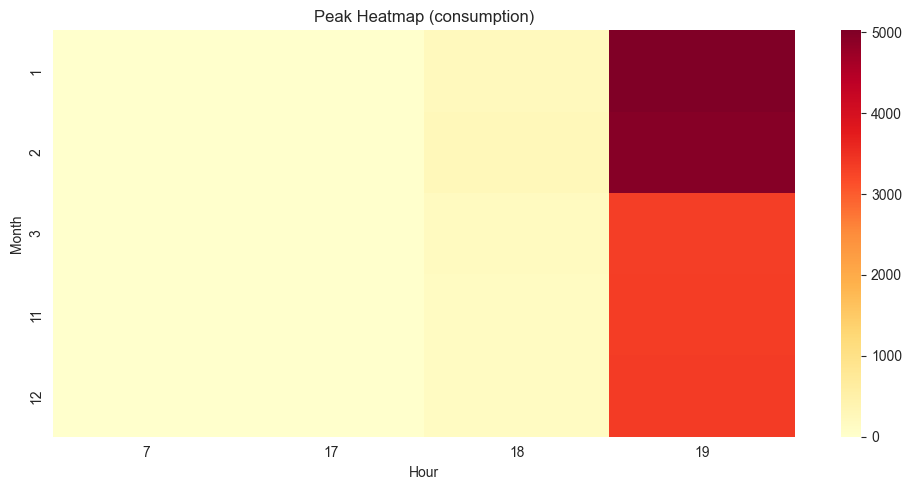

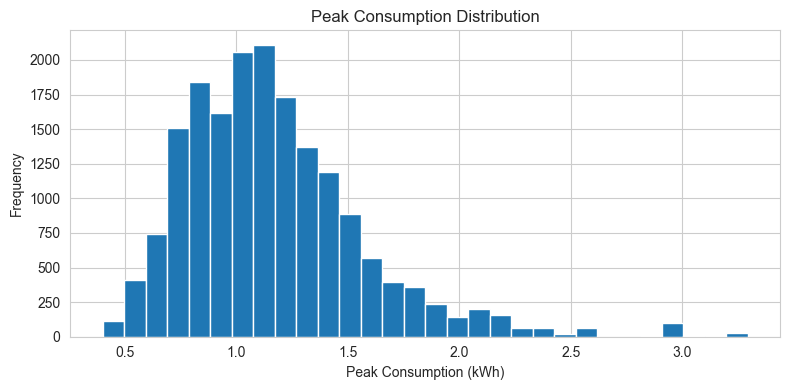

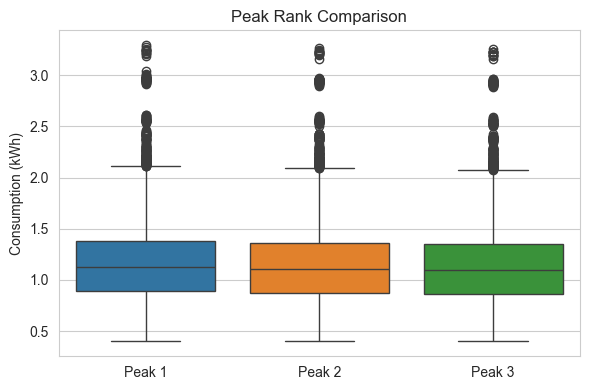

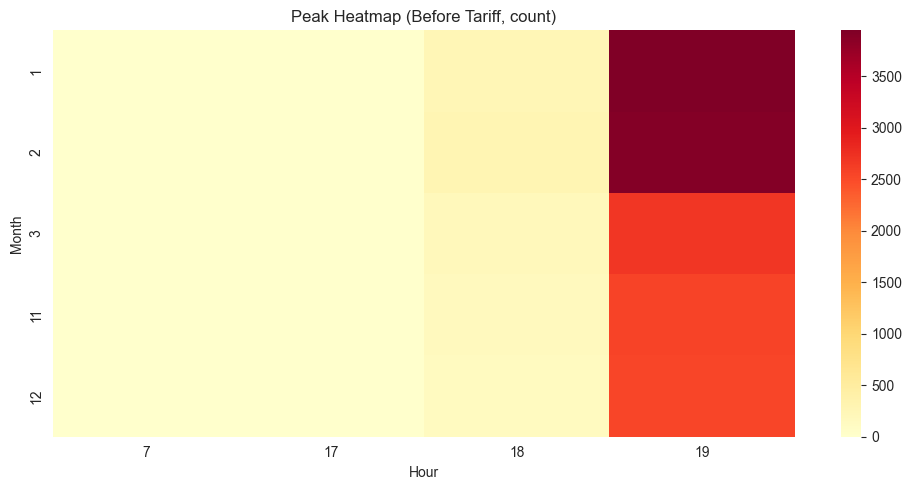

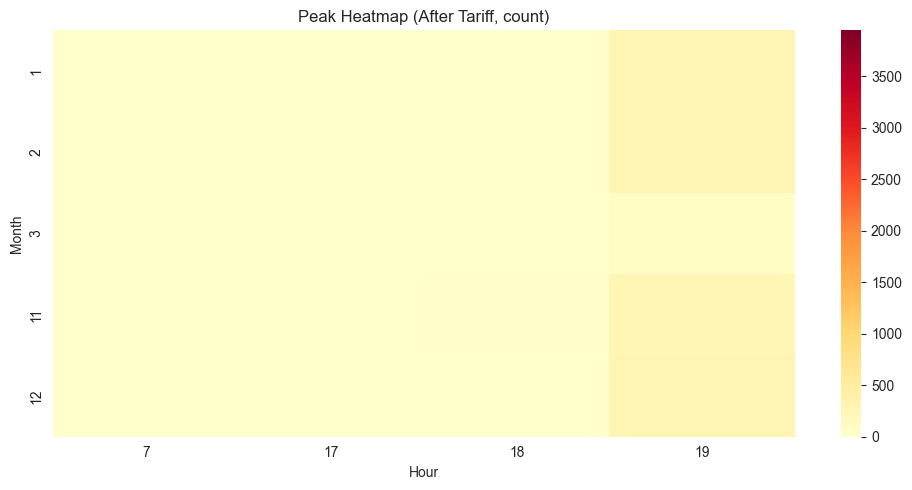

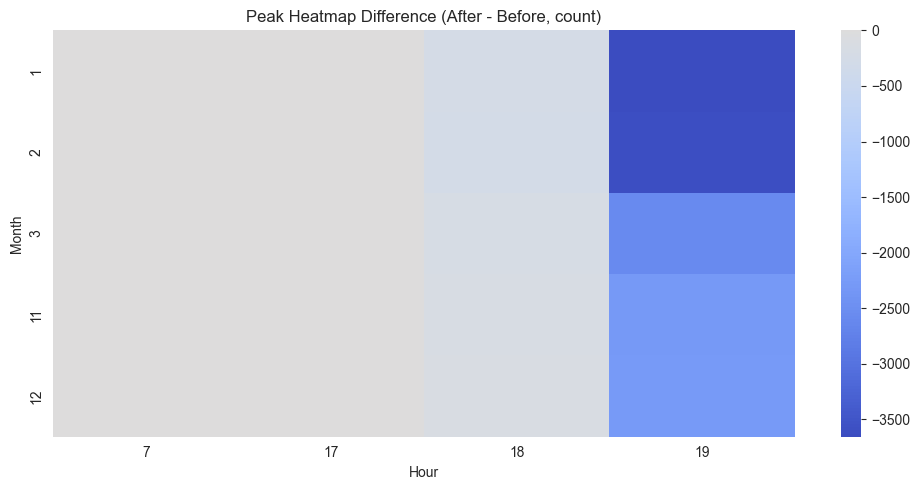

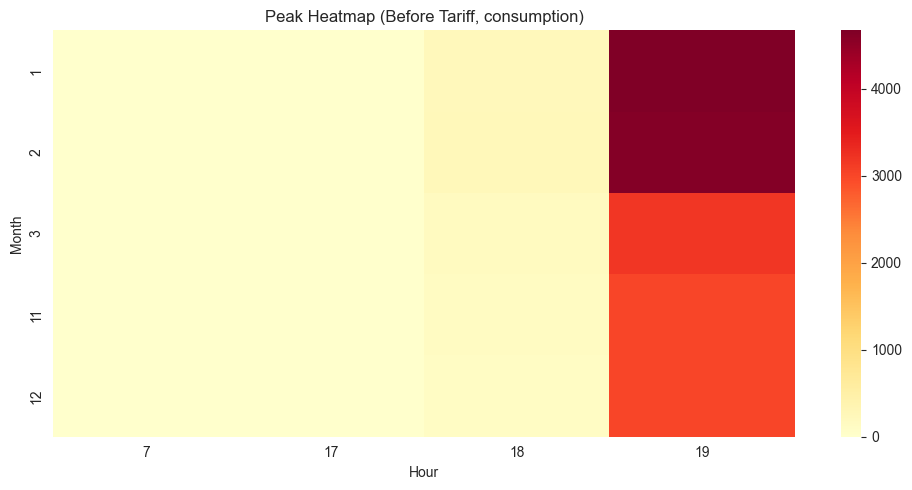

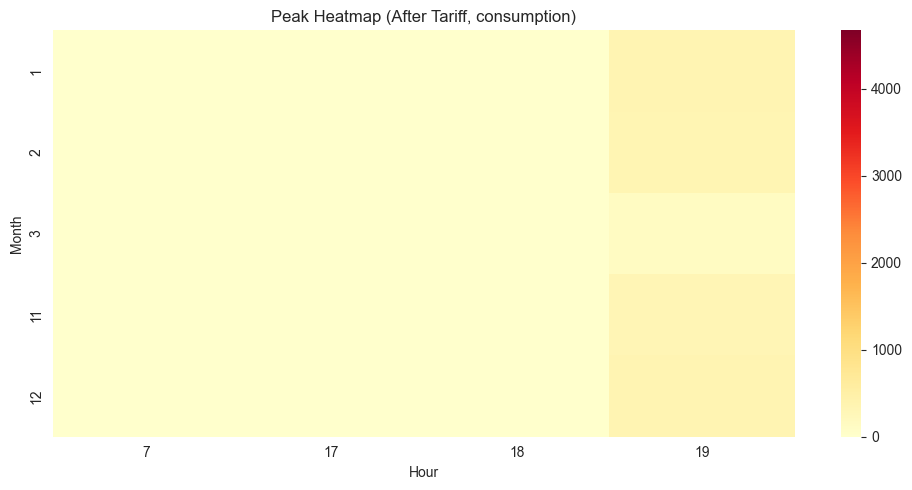

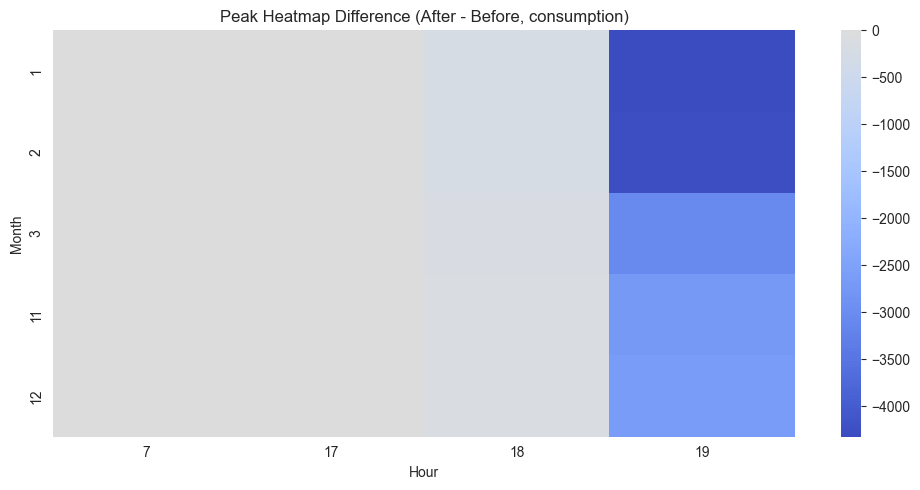

In [23]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
pp.plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Tariff peak heatmap (count)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"]
)

# Tariff peak heatmap (consumption)
# 比較 tariff 前後 peak 用電量的 Month × Hour heatmap
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

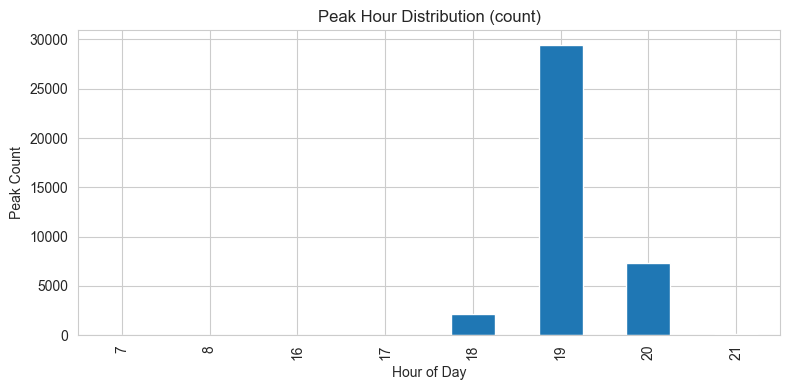

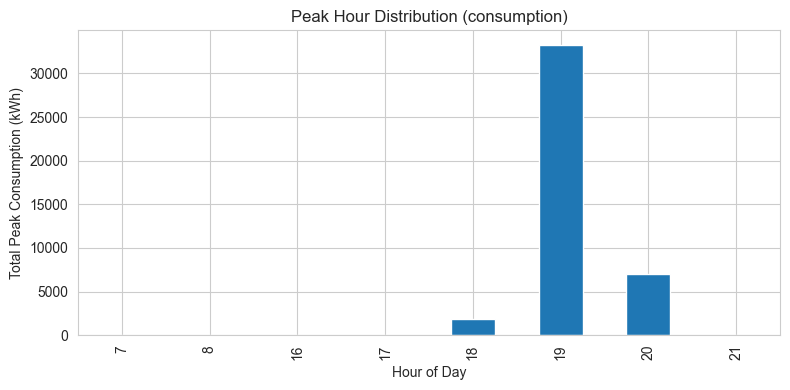

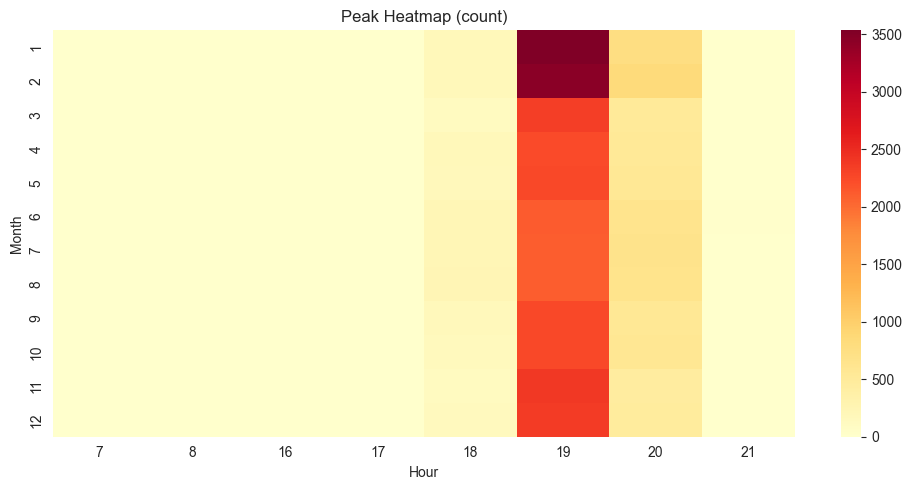

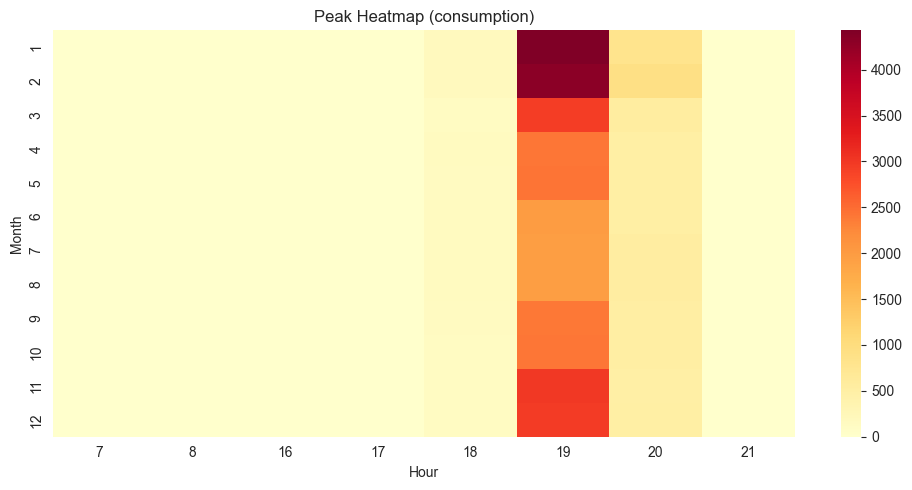

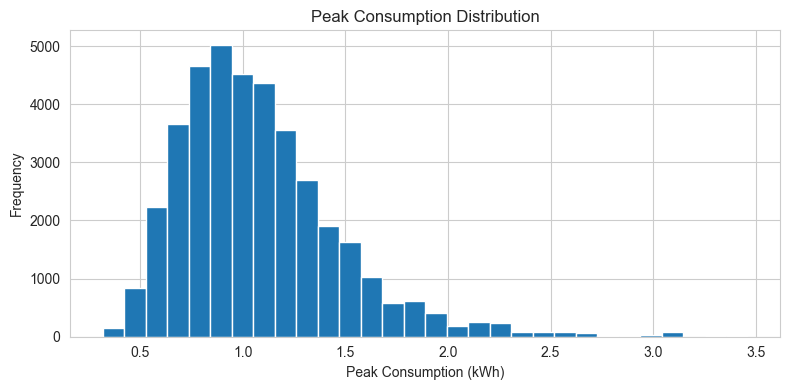

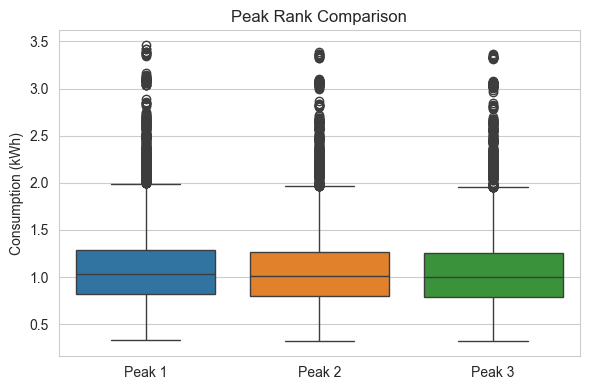

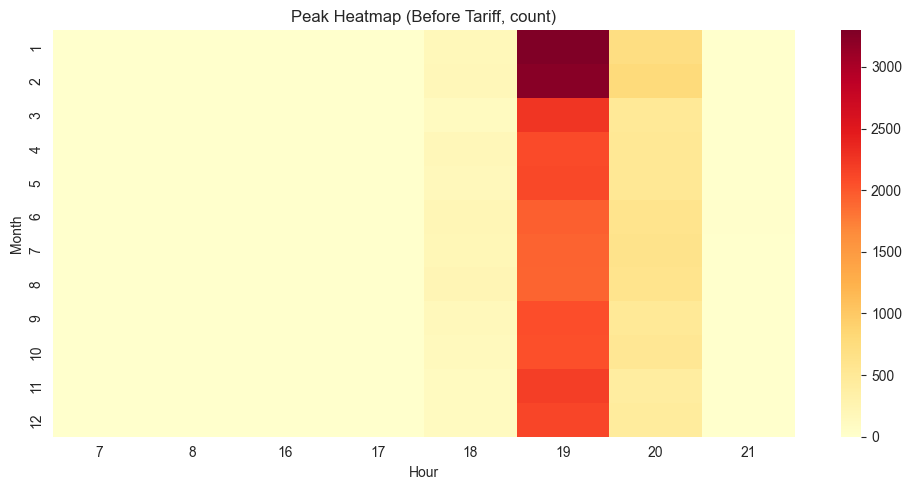

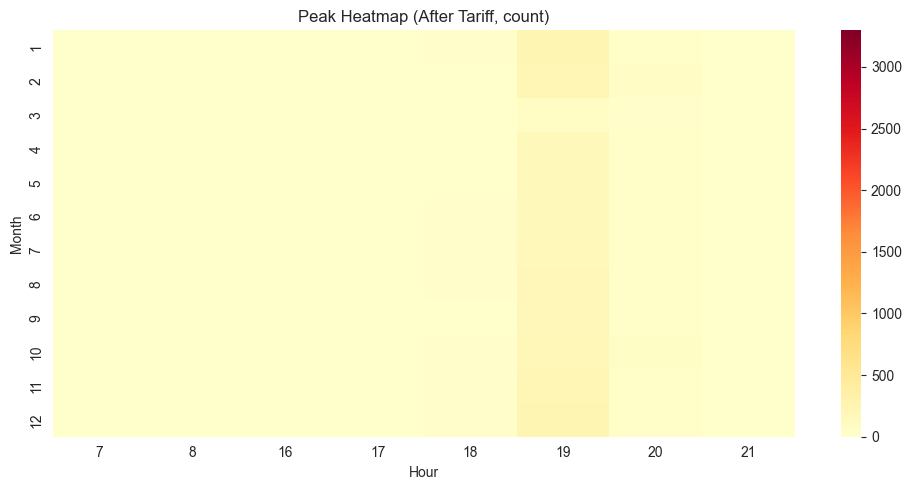

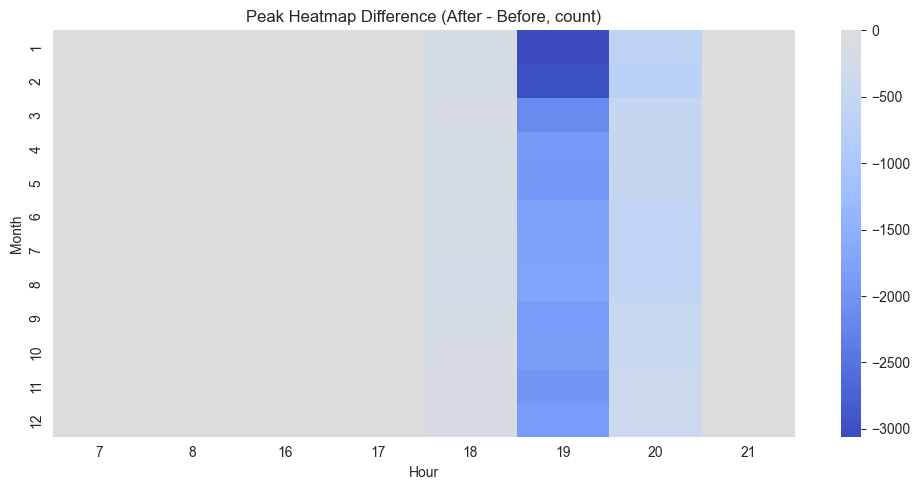

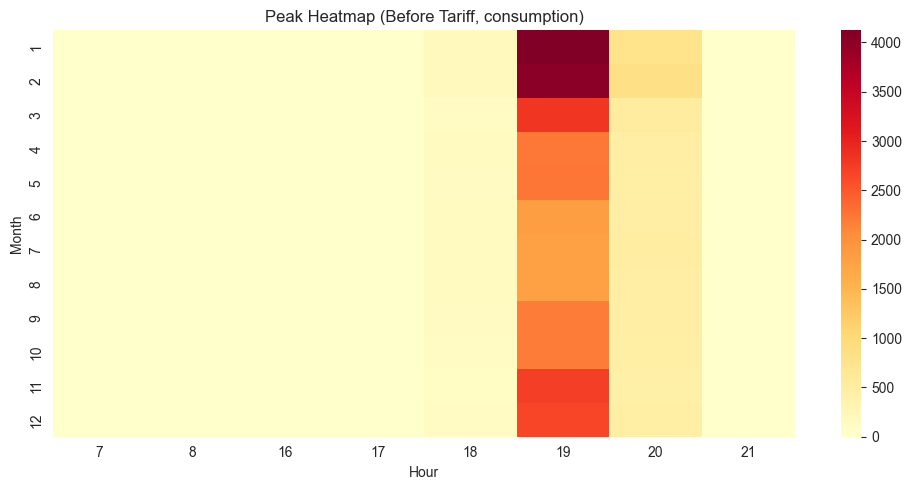

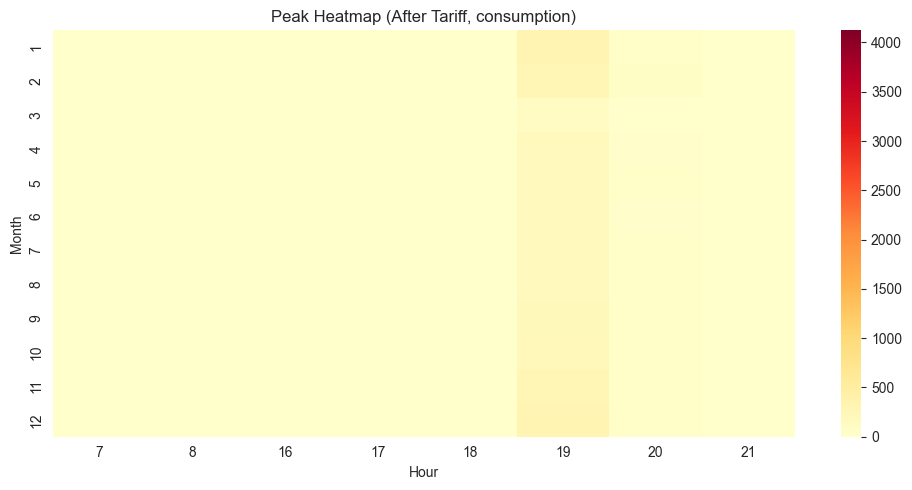

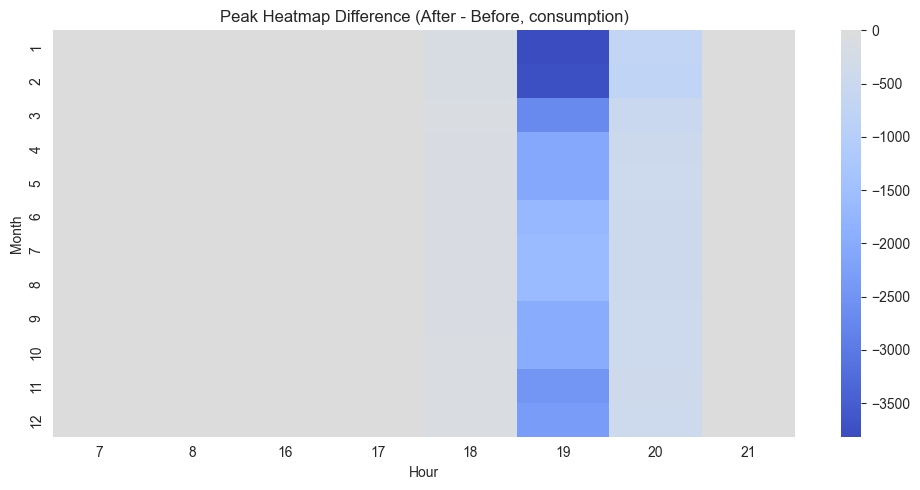

In [24]:
# Overall peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Tariff peak heatmap (count)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"]
)

# Tariff peak heatmap (consumption)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

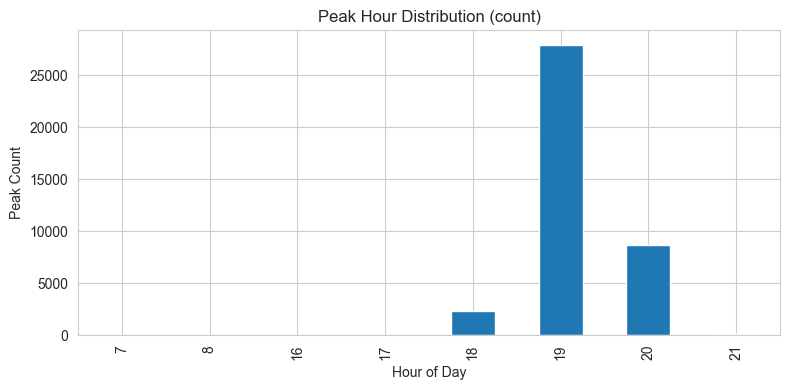

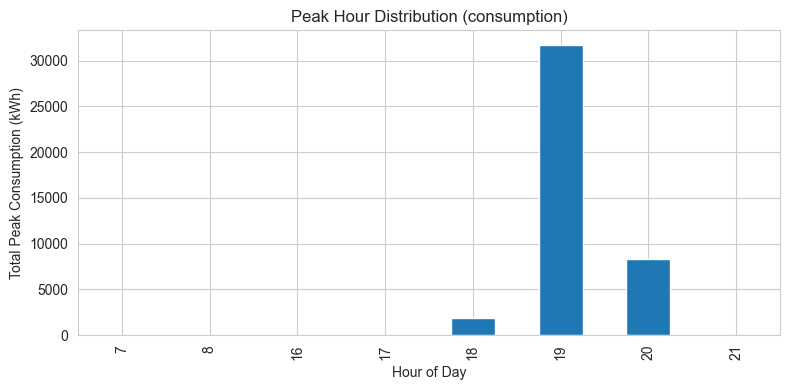

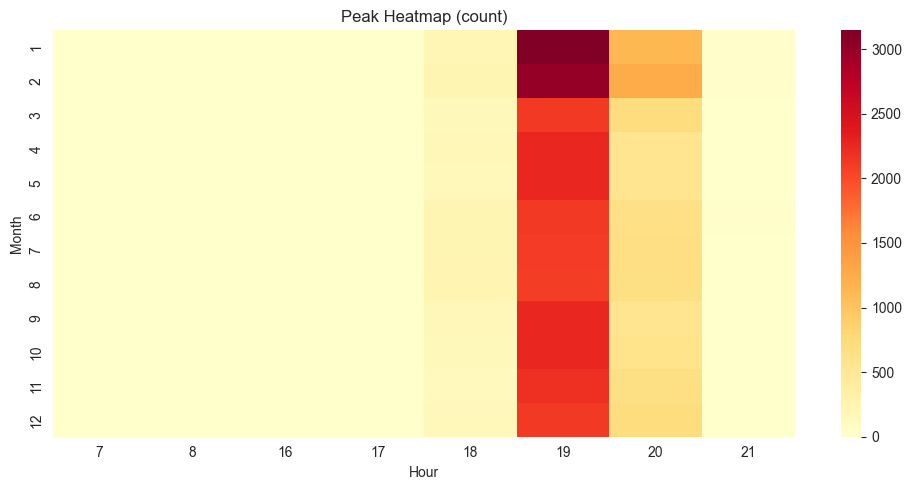

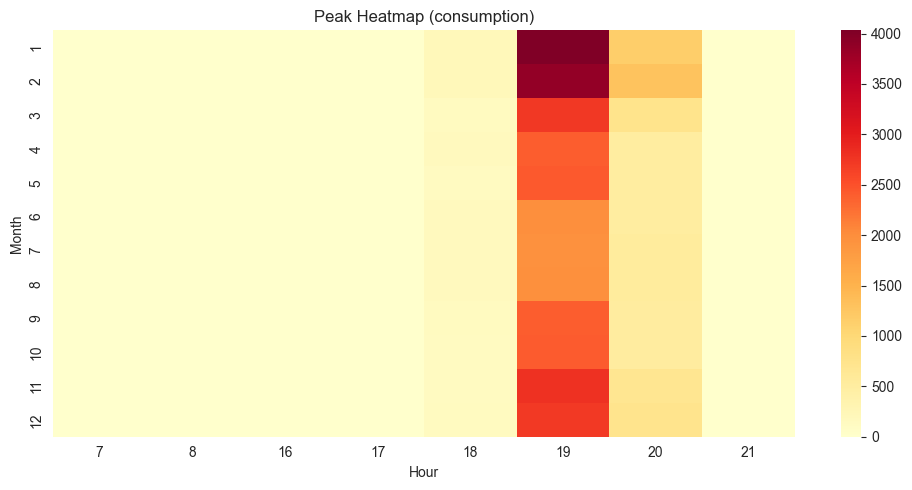

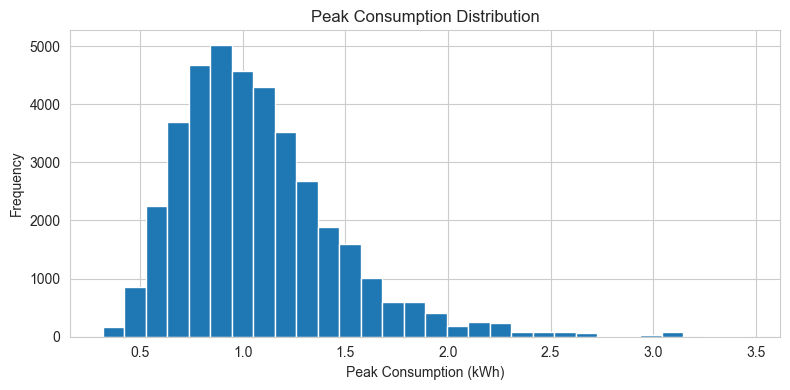

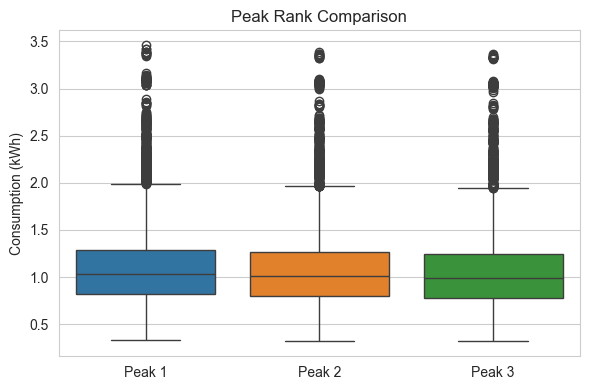

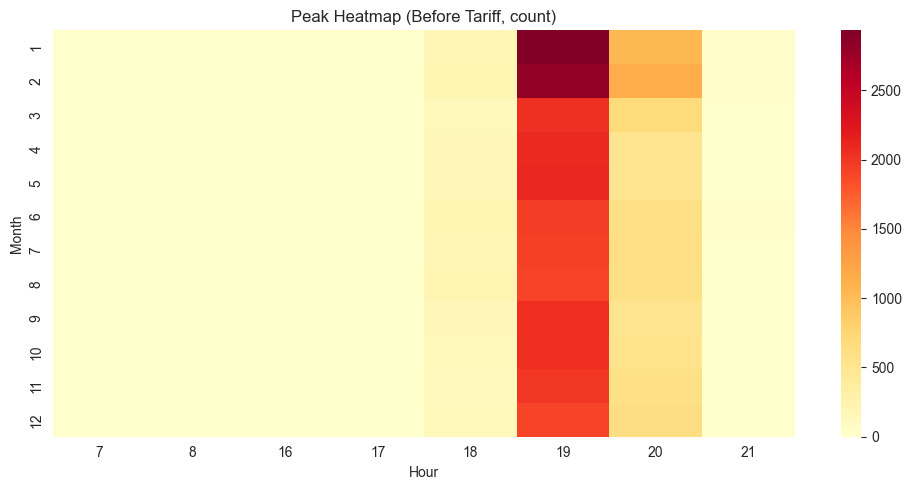

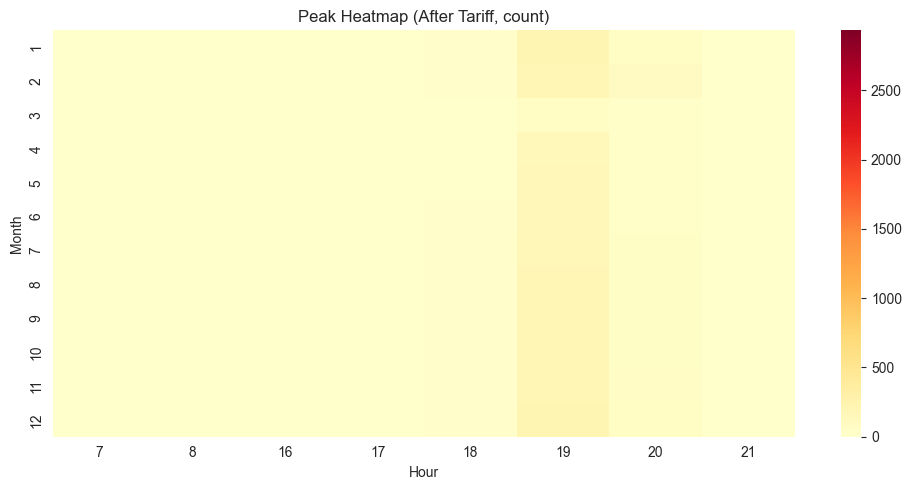

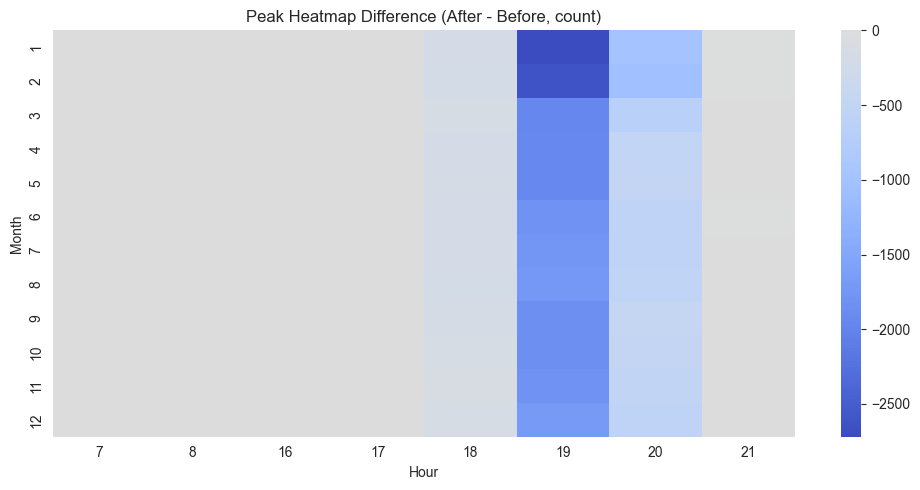

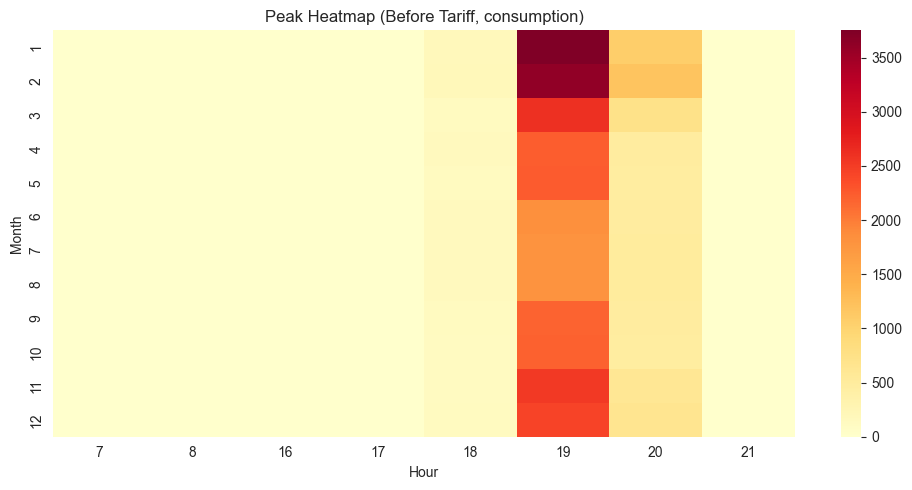

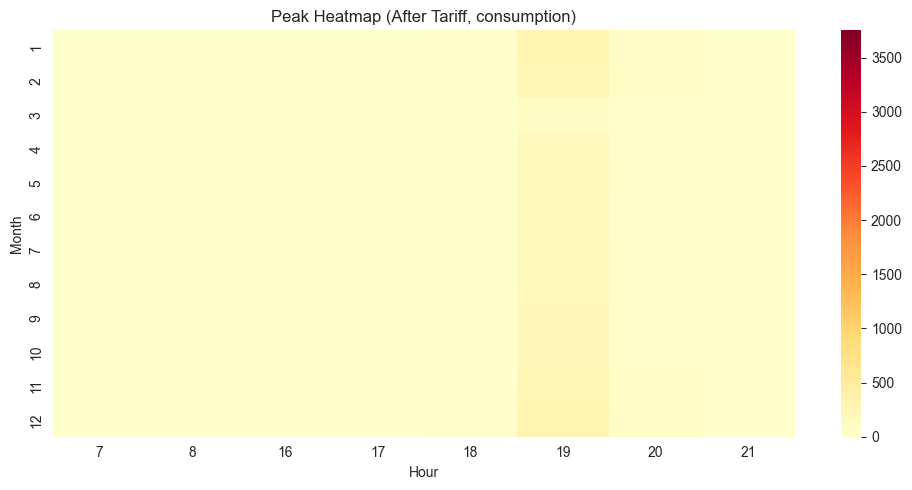

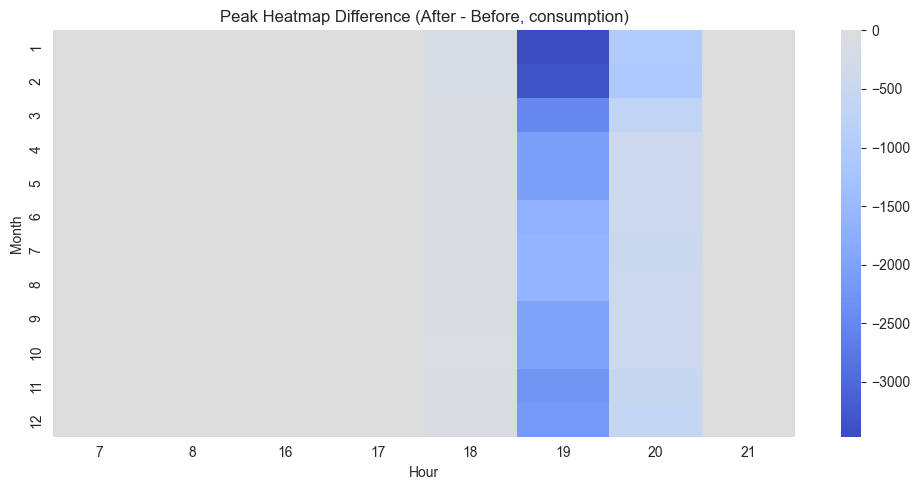

In [26]:
# Low peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Tariff peak heatmap (count)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"]
)

# Tariff peak heatmap (consumption)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)